In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("dataset-tickets-multi-lang-4-20k.csv")

# Check shape
print("Shape:", df.shape)

# Show first 5 rows
df.head()

Shape: (20000, 15)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [4]:
# Check columns
print(df.columns)

# Check missing values
print(df.isnull().sum())

# Check unique values in 'type'
print("Unique type labels:", df["type"].unique())
print("Number of unique labels:", df["type"].nunique())

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
      dtype='object')
subject      1461
body            2
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64
Unique type labels: ['Incident' 'Request' 'Problem' 'Change']
Number of unique labels: 4


In [5]:
# Combine subject and body into one text column
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

# Keep only required columns
df = df[["text", "type"]]

df.head()

,text,type
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Incident
1,Customer Support Inquiry Seeking information o...,Request
2,Data Analytics for Investment I am contacting ...,Request
3,Krankenhaus-Dienstleistung-Problem Ein Medien-...,Incident
4,"Security Dear Customer Support, I am reaching ...",Request


In [6]:
# Light cleaning
df["text"] = df["text"].str.lower().str.strip()

df.head()

,text,type
0,unvorhergesehener absturz der datenanalyse-pla...,Incident
1,customer support inquiry seeking information o...,Request
2,data analytics for investment i am contacting ...,Request
3,krankenhaus-dienstleistung-problem ein medien-...,Incident
4,"security dear customer support, i am reaching ...",Request


In [7]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["type"]

# First split train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 14000
Validation size: 3000
Test size: 3000


In [8]:
!pip uninstall numpy -y

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\patel\anaconda3\Lib\site-packages\pip\_vend

In [9]:
!pip install "numpy<2"

  Obtaining dependency information for numpy<2 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gradio 4.31.5 requires pillow<11.0,>=8.0, but you have pillow 11.3.0 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.
streamlit 1.33.0 requires pillow<11,>=7.1.0, but you have pillow 11.3.0 which is incompatible.


In [10]:
import numpy
print(numpy.__version__)

1.26.4


In [11]:
import numpy
print(numpy.__version__)

1.26.4


In [12]:
import pandas as pd

df = pd.read_csv("dataset-tickets-multi-lang-4-20k.csv")

print("Shape:", df.shape)
df.head()

Shape: (20000, 15)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [13]:
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")
df = df[["text", "type"]]

df.head()

,text,type
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Incident
1,Customer Support Inquiry Seeking information o...,Request
2,Data Analytics for Investment I am contacting ...,Request
3,Krankenhaus-Dienstleistung-Problem Ein Medien-...,Incident
4,"Security Dear Customer Support, I am reaching ...",Request


In [14]:
df["text"] = df["text"].str.lower().str.strip()

In [15]:
print(df["type"].value_counts())

type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64


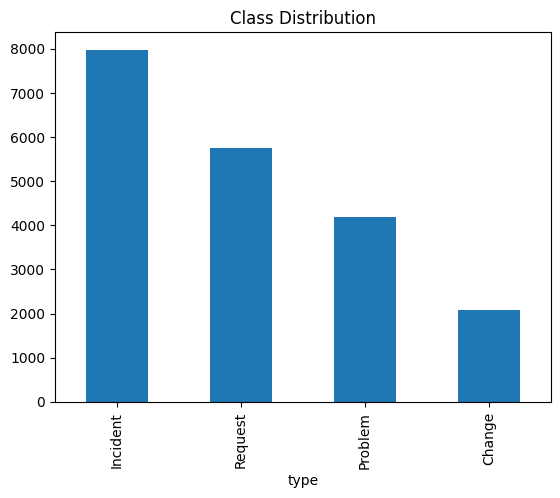

In [16]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["type"]

# First split train vs temp (70% train)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 14000
Validation: 3000
Test: 3000


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)  # unigram only for baseline
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)

TF-IDF train shape: (14000, 5000)


In [19]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import classification_report

# Predict on validation
y_val_pred = model.predict(X_val_tfidf)

# Print report
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

      Change       0.98      0.88      0.93       311
    Incident       0.71      0.88      0.79      1197
     Problem       0.60      0.33      0.43       627
     Request       0.96      0.99      0.98       865

    accuracy                           0.80      3000
   macro avg       0.81      0.77      0.78      3000
weighted avg       0.79      0.80      0.78      3000



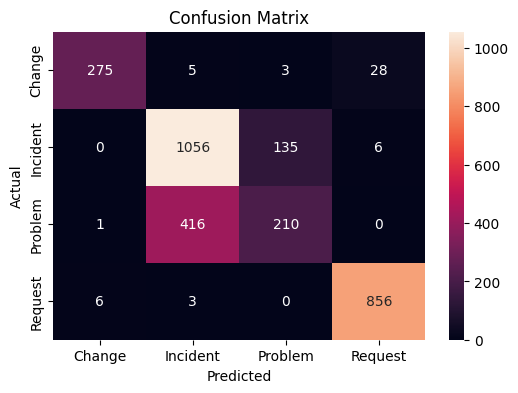

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
tfidf_bigram = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)  # unigram + bigram
)

X_train_bigram = tfidf_bigram.fit_transform(X_train)
X_val_bigram = tfidf_bigram.transform(X_val)

model_bigram = LogisticRegression(max_iter=1000)
model_bigram.fit(X_train_bigram, y_train)

y_val_pred_bigram = model_bigram.predict(X_val_bigram)

print(classification_report(y_val, y_val_pred_bigram))

              precision    recall  f1-score   support

      Change       0.97      0.88      0.92       311
    Incident       0.71      0.87      0.78      1197
     Problem       0.57      0.34      0.42       627
     Request       0.96      0.99      0.98       865

    accuracy                           0.79      3000
   macro avg       0.80      0.77      0.78      3000
weighted avg       0.78      0.79      0.78      3000



In [23]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train_tfidf, y_train)

y_val_pred_balanced = model_balanced.predict(X_val_tfidf)

print(classification_report(y_val, y_val_pred_balanced))

              precision    recall  f1-score   support

      Change       0.90      0.94      0.92       311
    Incident       0.75      0.69      0.72      1197
     Problem       0.49      0.57      0.53       627
     Request       0.98      0.97      0.97       865

    accuracy                           0.77      3000
   macro avg       0.78      0.79      0.78      3000
weighted avg       0.78      0.77      0.77      3000



In [24]:
!pip install sentence-transformers

In [25]:
from sentence_transformers import SentenceTransformer

# Load small efficient model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [ ]:
# Generate embeddings for training and validation
X_train_embed = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_val_embed = embedding_model.encode(
    X_val.tolist(),
    show_progress_bar=True
)

print("Train embedding shape:", X_train_embed.shape)

Batches:   0%|          | 0/438 [00:00<?, ?it/s]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Train classifier on embeddings
model_embed = LogisticRegression(max_iter=1000)
model_embed.fit(X_train_embed, y_train)

# Predict on validation
y_val_pred_embed = model_embed.predict(X_val_embed)

# Print results
print(classification_report(y_val, y_val_pred_embed))

In [ ]:
model_embed_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_embed_balanced.fit(X_train_embed, y_train)

y_val_pred_embed_bal = model_embed_balanced.predict(X_val_embed)

print(classification_report(y_val, y_val_pred_embed_bal))

In [ ]:
!pip install faiss-cpu

In [ ]:
import faiss
import numpy as np

# Convert to float32 (FAISS requires float32)
X_train_embed_np = np.array(X_train_embed).astype("float32")

# Get dimension
dimension = X_train_embed_np.shape[1]

# Create index
index = faiss.IndexFlatL2(dimension)

# Add vectors to index
index.add(X_train_embed_np)

print("Number of vectors in index:", index.ntotal)

In [ ]:
def search_similar_tickets(query_text, top_k=3):
    # Convert query to embedding
    query_vector = embedding_model.encode([query_text])
    query_vector = np.array(query_vector).astype("float32")
    
    # Search in FAISS index
    distances, indices = index.search(query_vector, top_k)
    
    return distances, indices

In [ ]:
query = "I cannot login to my account"

distances, indices = search_similar_tickets(query)

print("Indices:", indices)
print("Distances:", distances)

In [ ]:
# Convert X_train to list for indexing
train_texts = X_train.tolist()
train_labels = y_train.tolist()

for idx in indices[0]:
    print("-----")
    print("Label:", train_labels[idx])
    print("Text:", train_texts[idx][:200])

In [ ]:
results_summary = pd.DataFrame({
    "Model": [
        "TFIDF Unigram",
        "TFIDF Bigram",
        "TFIDF Balanced",
        "Embedding Logistic"
    ],
    "Validation Accuracy": [
        0.80,   # replace with your actual numbers
        0.79,
        0.82,
        0.84
    ]
})

results_summary